In [1]:
import polars as pl
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
votus = pl.read_csv("./votu_master.tsv", separator="\t")

In [3]:
coverm = pl.read_csv("./coverm.tsv", separator="\t")

In [4]:
meta = pl.read_csv("/media/yasas-wijesekara/Bender/ATLAS_mouse/Metagenomics_barrier_dysfunction_project/250606_16S_Seq_Kenneth_MG005H.csv")

In [5]:
meta

16S_ID,Mouse Number/Control,Mock/Tumor,Feces/Cecum/Control/CRC,,Concentration [ng/µL],Date of extraction,_duplicated_0
str,str,str,str,str,f64,i64,str
"""Kenneth_001""","""SZ-AL18""","""Tumor""","""Ileum""","""DNA""",8.3,250608,"""metagenomics failed"""
"""Kenneth_002""","""SZ-AL19""","""Tumor""","""Ileum""","""DNA""",55.5,250608,"""metagenomics failed"""
"""Kenneth_003""","""SZ-AL36""","""Tumor""","""Ileum""","""DNA""",8.74,250608,"""metagenomics failed"""
"""Kenneth_004""","""SZ-AN56""","""Tumor""","""Ileum""","""DNA""",4.13,250608,null
"""Kenneth_005""","""SZ-Y878""","""Tumor""","""Ileum""","""DNA""",7.79,250608,null
…,…,…,…,…,…,…,…
"""Kenneth_024""","""SZ-AN97""","""Mock""","""Cecum""","""DNA""",222.52,250608,null
"""Kenneth_025""","""SZ-AN98""","""Mock""","""Cecum""","""DNA""",246.67,250608,null
"""Kenneth_026""","""SZ-Y988""","""Mock""","""Cecum""","""DNA""",259.04,250608,null


In [6]:
meta = meta.with_columns(
    pl.col("16S_ID").str.replace("_", "")
)

In [7]:
votus

votu,representative,n_members,n_samples,rep_length,checkv_quality,completeness,contamination,taxonomy,lifestyle,lifestyle_score,amg_flag,host,host_score
i64,str,i64,i64,i64,str,f64,f64,str,str,f64,str,str,str
0,"""Kenneth017__Kenneth017_114""",31,17,56386,"""Low-quality""",30.58,0.0,"""Duplodnaviria;unplaced_kingdom…","""virulent""",0.746651,null,null,null
1,"""Kenneth025__Kenneth025_15""",30,17,154062,"""Complete""",100.0,69.66,"""Duplodnaviria;Heunggongvirae;U…","""virulent""",0.653269,null,null,null
10,"""Kenneth022__Kenneth022_289""",23,15,41647,"""Medium-quality""",64.71,0.0,"""Duplodnaviria;unplaced_kingdom…","""virulent""",0.765062,null,null,null
100,"""Kenneth009__Kenneth009_1451""",10,10,14633,"""Not-determined""",null,0.0,"""Duplodnaviria;unplaced_kingdom…","""virulent""",0.693302,null,null,null
1000,"""Kenneth017__Kenneth017_573""",1,1,21754,"""Low-quality""",45.2,0.0,"""Duplodnaviria;Heunggongvirae;U…","""temperate""",0.800951,null,null,null
…,…,…,…,…,…,…,…,…,…,…,…,…,…
995,"""Kenneth026__Kenneth026_1571""",1,1,21980,"""Not-determined""",null,0.0,"""Duplodnaviria;unplaced_kingdom…","""virulent""",0.654792,null,null,null
996,"""Kenneth020__Kenneth020_2192""",1,1,21941,"""Medium-quality""",60.63,0.0,"""Duplodnaviria;Heunggongvirae;U…","""virulent""",0.549775,null,null,null
997,"""Kenneth019__Kenneth019_2152""",1,1,21880,"""Medium-quality""",58.56,0.0,"""Duplodnaviria;Heunggongvirae;U…","""virulent""",0.698682,null,null,null


In [8]:
(votus
 .filter(pl.col("checkv_quality") != "Not-determined")
 .group_by("lifestyle")
 .len()
 .sort("len", descending=True))

lifestyle,len
str,u32
"""virulent""",572
"""temperate""",510


In [9]:
hq_representatives = votus.filter(pl.col("checkv_quality") != "Not-determined")[["representative", "lifestyle"]]
#hq_representatives = votus[["representative", "lifestyle"]]

In [10]:
hq_representatives

representative,lifestyle
str,str
"""Kenneth017__Kenneth017_114""","""virulent"""
"""Kenneth025__Kenneth025_15""","""virulent"""
"""Kenneth022__Kenneth022_289""","""virulent"""
"""Kenneth017__Kenneth017_573""","""temperate"""
"""Kenneth013__Kenneth013_803""","""temperate"""
…,…
"""Kenneth028__Kenneth028_1874""","""virulent"""
"""Kenneth024__Kenneth024_2349""","""virulent"""
"""Kenneth020__Kenneth020_2192""","""virulent"""


In [11]:
data = hq_representatives.join(coverm, left_on="representative", right_on="contig")#.drop("contig")

In [12]:
data

representative,lifestyle,Kenneth004,Kenneth005,Kenneth006,Kenneth007,Kenneth008,Kenneth009,Kenneth010,Kenneth011,Kenneth013,Kenneth014,Kenneth015,Kenneth016,Kenneth017,Kenneth018,Kenneth019,Kenneth020,Kenneth021,Kenneth022,Kenneth023,Kenneth024,Kenneth025,Kenneth026,Kenneth027,Kenneth028
str,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""Kenneth004__Kenneth004_106""","""temperate""",1604.3208,100.41081,5.935806,9.027764,87.599915,39.800354,16.358587,46.78135,2.8349693,5.881239,59.614452,108.16506,85.34891,345.18903,111.02641,24.005766,11.612061,115.54426,882.1312,130.83618,168.3068,49.89979,34.307205,32.32332
"""Kenneth004__Kenneth004_298""","""temperate""",4908.3394,259.09543,230.05493,292.7191,2554.242,735.7609,432.79684,923.4778,792.5847,348.1267,305.77097,314.08185,297.44046,1144.6881,666.10004,552.8842,7.251315,1233.0176,507.50922,841.7511,1057.5807,596.06555,474.7916,499.62006
"""Kenneth004__Kenneth004_347""","""temperate""",6124.758,58.086002,28.278044,153.82785,2720.2395,780.24255,815.13885,76.891594,201.4482,77.91707,53.734505,64.90791,85.2334,626.4662,137.8933,35.29871,0.821071,984.8344,635.6993,459.53165,76.36295,322.80237,73.05711,49.81416
"""Kenneth005__Kenneth005_49""","""temperate""",110.51712,13277.234,564.03705,5020.2705,595.6658,120.56459,312.6939,117.50022,1318.5725,339.94678,47.492767,19.033674,24.65213,0.0,90.736275,67.3857,486.73608,57.836983,33.993572,22.630957,19.335604,151.67438,97.11391,34.00116
"""Kenneth006__Kenneth006_129""","""temperate""",2970.8752,11674.376,33743.64,2504.178,4822.7285,705.9964,1733.9409,9538.008,1360.6257,6751.6284,59.609905,5.470219,19.295227,0.0,252.24025,20.750546,0.0,67.49195,12.66891,46.891674,147.88416,76.72488,54.25608,39.372475
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""Kenneth028__Kenneth028_89""","""virulent""",30.553001,725.6189,66.148544,61.72112,18.92668,18.80014,59.61576,145.31372,77.588135,94.571236,231.48389,183.75613,254.27606,201.38577,756.395,847.7203,723.4952,51.990208,113.5172,130.45369,33.96214,249.35742,525.13434,872.9944
"""Kenneth028__Kenneth028_891""","""virulent""",52.84596,225.21509,556.3728,1030.4045,164.3597,1179.888,50.249306,63.069077,286.6044,427.78604,175.7882,186.06622,199.22015,184.7544,370.84482,764.2069,398.81516,120.043365,607.0743,348.43146,326.5184,620.3172,949.60175,950.8918
"""Kenneth028__Kenneth028_917""","""temperate""",11.394242,60.29158,1.2185123,5.765621,0.0,0.2122151,0.0,0.0,4.655736,9.658481,32.416172,66.46674,53.30332,0.0,56.25686,102.73152,238.99352,4.660823,26.91345,8.272926,3.7251039,144.88475,30.525393,233.719


In [13]:
data_long = data.unpivot(
    index=["representative", "lifestyle"],
    variable_name="sample",
    value_name="abundance",
)

In [14]:
data_long

representative,lifestyle,sample,abundance
str,str,str,f64
"""Kenneth004__Kenneth004_106""","""temperate""","""Kenneth004""",1604.3208
"""Kenneth004__Kenneth004_298""","""temperate""","""Kenneth004""",4908.3394
"""Kenneth004__Kenneth004_347""","""temperate""","""Kenneth004""",6124.758
"""Kenneth005__Kenneth005_49""","""temperate""","""Kenneth004""",110.51712
"""Kenneth006__Kenneth006_129""","""temperate""","""Kenneth004""",2970.8752
…,…,…,…
"""Kenneth028__Kenneth028_89""","""virulent""","""Kenneth028""",872.9944
"""Kenneth028__Kenneth028_891""","""virulent""","""Kenneth028""",950.8918
"""Kenneth028__Kenneth028_917""","""temperate""","""Kenneth028""",233.719


In [15]:
df = data_long.join(
    meta.select(["Feces/Cecum/Control/CRC", "Mock/Tumor", "16S_ID"]),
    left_on="sample",
    right_on="16S_ID",
)

In [16]:
df

representative,lifestyle,sample,abundance,Feces/Cecum/Control/CRC,Mock/Tumor
str,str,str,f64,str,str
"""Kenneth004__Kenneth004_106""","""temperate""","""Kenneth004""",1604.3208,"""Ileum""","""Tumor"""
"""Kenneth004__Kenneth004_298""","""temperate""","""Kenneth004""",4908.3394,"""Ileum""","""Tumor"""
"""Kenneth004__Kenneth004_347""","""temperate""","""Kenneth004""",6124.758,"""Ileum""","""Tumor"""
"""Kenneth005__Kenneth005_49""","""temperate""","""Kenneth004""",110.51712,"""Ileum""","""Tumor"""
"""Kenneth006__Kenneth006_129""","""temperate""","""Kenneth004""",2970.8752,"""Ileum""","""Tumor"""
…,…,…,…,…,…
"""Kenneth028__Kenneth028_89""","""virulent""","""Kenneth028""",872.9944,"""Cecum""","""Mock"""
"""Kenneth028__Kenneth028_891""","""virulent""","""Kenneth028""",950.8918,"""Cecum""","""Mock"""
"""Kenneth028__Kenneth028_917""","""temperate""","""Kenneth028""",233.719,"""Cecum""","""Mock"""


<Axes: xlabel='Mock/Tumor', ylabel='abundance'>

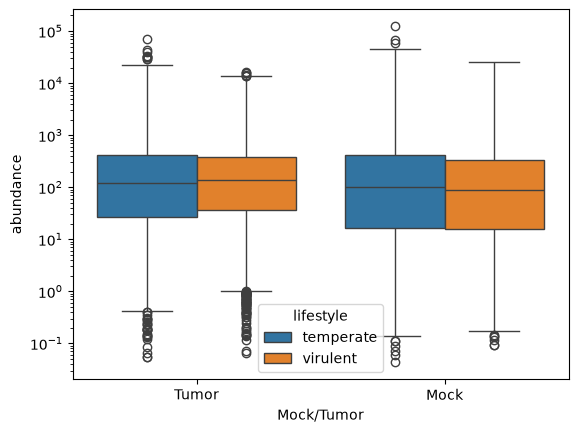

In [17]:
sns.boxplot(df, x="Mock/Tumor", y="abundance", log_scale=True, hue="lifestyle")

<Axes: xlabel='Feces/Cecum/Control/CRC', ylabel='abundance'>

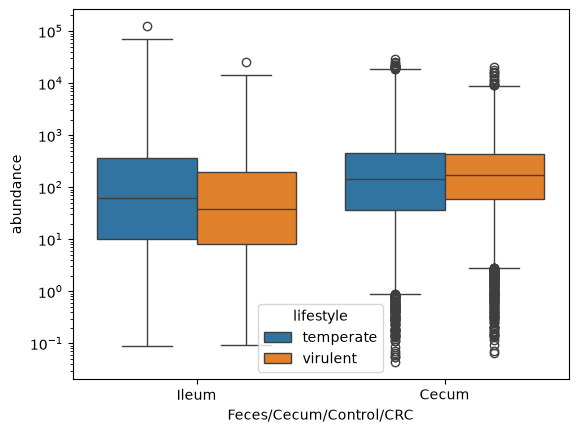

In [18]:
sns.boxplot(df, x="Feces/Cecum/Control/CRC", y="abundance", log_scale=True, hue="lifestyle")

In [37]:
df.head()

representative,lifestyle,sample,abundance,Feces/Cecum/Control/CRC,Mock/Tumor
str,str,str,f64,str,str
"""Kenneth004__Kenneth004_106""","""temperate""","""Kenneth004""",1604.3208,"""Ileum""","""Tumor"""
"""Kenneth004__Kenneth004_298""","""temperate""","""Kenneth004""",4908.3394,"""Ileum""","""Tumor"""
"""Kenneth004__Kenneth004_347""","""temperate""","""Kenneth004""",6124.758,"""Ileum""","""Tumor"""
"""Kenneth005__Kenneth005_49""","""temperate""","""Kenneth004""",110.51712,"""Ileum""","""Tumor"""
"""Kenneth006__Kenneth006_129""","""temperate""","""Kenneth004""",2970.8752,"""Ileum""","""Tumor"""


In [20]:
## P_temperate = sum(abundance of temperate vOTUs in sample) / (sum(abundance of temperate vOTUs) + sum(abundance of lytic vOTUs))

In [21]:
df.head()

representative,lifestyle,sample,abundance,Feces/Cecum/Control/CRC,Mock/Tumor
str,str,str,f64,str,str
"""Kenneth004__Kenneth004_106""","""temperate""","""Kenneth004""",1604.3208,"""Ileum""","""Tumor"""
"""Kenneth004__Kenneth004_298""","""temperate""","""Kenneth004""",4908.3394,"""Ileum""","""Tumor"""
"""Kenneth004__Kenneth004_347""","""temperate""","""Kenneth004""",6124.758,"""Ileum""","""Tumor"""
"""Kenneth005__Kenneth005_49""","""temperate""","""Kenneth004""",110.51712,"""Ileum""","""Tumor"""
"""Kenneth006__Kenneth006_129""","""temperate""","""Kenneth004""",2970.8752,"""Ileum""","""Tumor"""


In [22]:
result = df.group_by("sample").agg(
    (
        pl.col("abundance").filter(pl.col("lifestyle") == "temperate").sum()
        / pl.col("abundance").sum()
    ).alias("p_temperate"),
)

In [23]:
meta

16S_ID,Mouse Number/Control,Mock/Tumor,Feces/Cecum/Control/CRC,,Concentration [ng/µL],Date of extraction,_duplicated_0
str,str,str,str,str,f64,i64,str
"""Kenneth001""","""SZ-AL18""","""Tumor""","""Ileum""","""DNA""",8.3,250608,"""metagenomics failed"""
"""Kenneth002""","""SZ-AL19""","""Tumor""","""Ileum""","""DNA""",55.5,250608,"""metagenomics failed"""
"""Kenneth003""","""SZ-AL36""","""Tumor""","""Ileum""","""DNA""",8.74,250608,"""metagenomics failed"""
"""Kenneth004""","""SZ-AN56""","""Tumor""","""Ileum""","""DNA""",4.13,250608,null
"""Kenneth005""","""SZ-Y878""","""Tumor""","""Ileum""","""DNA""",7.79,250608,null
…,…,…,…,…,…,…,…
"""Kenneth024""","""SZ-AN97""","""Mock""","""Cecum""","""DNA""",222.52,250608,null
"""Kenneth025""","""SZ-AN98""","""Mock""","""Cecum""","""DNA""",246.67,250608,null
"""Kenneth026""","""SZ-Y988""","""Mock""","""Cecum""","""DNA""",259.04,250608,null


In [24]:
result = result.join(
    meta.select(["Feces/Cecum/Control/CRC", "Mock/Tumor", "16S_ID", "Mouse Number/Control"]),
    left_on="sample",
    right_on="16S_ID",
)

In [25]:
result

sample,p_temperate,Feces/Cecum/Control/CRC,Mock/Tumor,Mouse Number/Control
str,f64,str,str,str
"""Kenneth004""",0.821485,"""Ileum""","""Tumor""","""SZ-AN56"""
"""Kenneth005""",0.691811,"""Ileum""","""Tumor""","""SZ-Y878"""
"""Kenneth006""",0.720469,"""Ileum""","""Tumor""","""SZ-Y941"""
"""Kenneth007""",0.386311,"""Ileum""","""Tumor""","""SZ-Y943"""
"""Kenneth008""",0.754183,"""Ileum""","""Mock""","""SZ-AN66"""
…,…,…,…,…
"""Kenneth024""",0.557398,"""Cecum""","""Mock""","""SZ-AN97"""
"""Kenneth025""",0.769235,"""Cecum""","""Mock""","""SZ-AN98"""
"""Kenneth026""",0.467189,"""Cecum""","""Mock""","""SZ-Y988"""


/tmp/ipykernel_1688242/2126092447.py:6: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.stripplot(result, x="Feces/Cecum/Control/CRC", y="p_temperate", hue="Mock/Tumor",


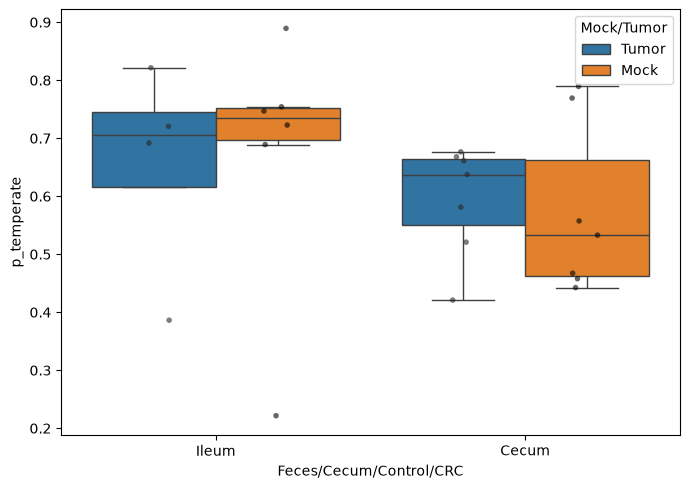

In [26]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7, 5))
sns.boxplot(result, x="Feces/Cecum/Control/CRC", y="p_temperate", hue="Mock/Tumor",
            ax=ax, showfliers=False)  # turn off default outlier markers, we'll add our own
sns.stripplot(result, x="Feces/Cecum/Control/CRC", y="p_temperate", hue="Mock/Tumor",
              dodge=True, ax=ax, color="black", size=4, alpha=0.6, legend=False)
plt.tight_layout()

In [27]:
type(result)

polars.dataframe.frame.DataFrame

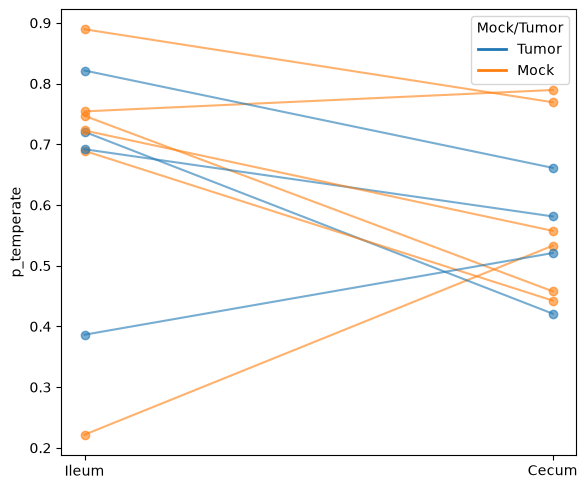

In [28]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

fig, ax = plt.subplots(figsize=(6, 5))
colors = {"Tumor": "#1f77b4", "Mock": "#ff7f0e"}

for mouse_id, sub in result.group_by("Mouse Number/Control"):
    sub_dict = {row["Feces/Cecum/Control/CRC"]: row["p_temperate"] for row in sub.iter_rows(named=True)}
    if "Ileum" not in sub_dict or "Cecum" not in sub_dict:
        continue  # mouse missing one site
    group = sub["Mock/Tumor"][0]
    ax.plot([0, 1], [sub_dict["Ileum"], sub_dict["Cecum"]], marker="o",
             color=colors[group], alpha=0.6, linewidth=1.5)

ax.set_xticks([0, 1])
ax.set_xticklabels(["Ileum", "Cecum"])
ax.set_ylabel("p_temperate")
handles = [Line2D([0], [0], color=c, lw=2, label=g) for g, c in colors.items()]
ax.legend(handles=handles, title="Mock/Tumor")
plt.tight_layout()

In [29]:
def flag_outliers(df, col="p_temperate"):
    q1, q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    return df.filter((pl.col(col) < lower) | (pl.col(col) > upper))

ileum_outliers = flag_outliers(result.filter(pl.col("Feces/Cecum/Control/CRC") == "Ileum"))
print(ileum_outliers)
outlier_samples = ileum_outliers["sample"].to_list()

shape: (3, 5)
┌────────────┬─────────────┬─────────────────────────┬────────────┬──────────────────────┐
│ sample     ┆ p_temperate ┆ Feces/Cecum/Control/CRC ┆ Mock/Tumor ┆ Mouse Number/Control │
│ ---        ┆ ---         ┆ ---                     ┆ ---        ┆ ---                  │
│ str        ┆ f64         ┆ str                     ┆ str        ┆ str                  │
╞════════════╪═════════════╪═════════════════════════╪════════════╪══════════════════════╡
│ Kenneth007 ┆ 0.386311    ┆ Ileum                   ┆ Tumor      ┆ SZ-Y943              │
│ Kenneth009 ┆ 0.221644    ┆ Ileum                   ┆ Mock       ┆ SZ-AN68              │
│ Kenneth011 ┆ 0.889434    ┆ Ileum                   ┆ Mock       ┆ SZ-AN98              │
└────────────┴─────────────┴─────────────────────────┴────────────┴──────────────────────┘


In [30]:
ileum = result.filter(pl.col("Feces/Cecum/Control/CRC") == "Ileum")

lowest = ileum.sort("p_temperate").head(1)
highest = ileum.sort("p_temperate", descending=True).head(1)

print(lowest)
print(highest)

outlier_samples = pl.concat([lowest, highest])["sample"].to_list()
print(outlier_samples)

shape: (1, 5)
┌────────────┬─────────────┬─────────────────────────┬────────────┬──────────────────────┐
│ sample     ┆ p_temperate ┆ Feces/Cecum/Control/CRC ┆ Mock/Tumor ┆ Mouse Number/Control │
│ ---        ┆ ---         ┆ ---                     ┆ ---        ┆ ---                  │
│ str        ┆ f64         ┆ str                     ┆ str        ┆ str                  │
╞════════════╪═════════════╪═════════════════════════╪════════════╪══════════════════════╡
│ Kenneth009 ┆ 0.221644    ┆ Ileum                   ┆ Mock       ┆ SZ-AN68              │
└────────────┴─────────────┴─────────────────────────┴────────────┴──────────────────────┘
shape: (1, 5)
┌────────────┬─────────────┬─────────────────────────┬────────────┬──────────────────────┐
│ sample     ┆ p_temperate ┆ Feces/Cecum/Control/CRC ┆ Mock/Tumor ┆ Mouse Number/Control │
│ ---        ┆ ---         ┆ ---                     ┆ ---        ┆ ---                  │
│ str        ┆ f64         ┆ str                     ┆ str    

In [31]:
import polars as pl

outlier_samples = ["Kenneth009", "Kenneth011"]
abundance = data_long
# 1. richness — how many vOTUs detected per sample
richness = (
    abundance
    .filter((pl.col("sample").is_in(outlier_samples)) & (pl.col("abundance") > 0))
    .group_by(["sample", "lifestyle"])
    .agg(pl.col("representative").n_unique().alias("n_votus"))
    .sort("sample")
)
print(richness)

# 2. dominance — is one vOTU carrying most of the sample's abundance
dominance = (
    abundance
    .filter(pl.col("sample").is_in(outlier_samples))
    .with_columns(
        (pl.col("abundance") / pl.col("abundance").sum().over("sample")).alias("rel_abund")
    )
    .sort(["sample", "rel_abund"], descending=[False, True])
)
print(dominance.group_by("sample").head(3))  # top 3 vOTUs per sample by rel_abund

# 3. total depth/abundance
depth_check = (
    abundance
    .group_by("sample")
    .agg(pl.col("abundance").sum().alias("total_cpm"))
    .sort("total_cpm")
)
print(depth_check)  # eyeball where Kenneth009 / Kenneth011 rank overall, not just relative to each other

shape: (4, 3)
┌────────────┬───────────┬─────────┐
│ sample     ┆ lifestyle ┆ n_votus │
│ ---        ┆ ---       ┆ ---     │
│ str        ┆ str       ┆ u32     │
╞════════════╪═══════════╪═════════╡
│ Kenneth009 ┆ virulent  ┆ 538     │
│ Kenneth009 ┆ temperate ┆ 455     │
│ Kenneth011 ┆ temperate ┆ 415     │
│ Kenneth011 ┆ virulent  ┆ 453     │
└────────────┴───────────┴─────────┘
shape: (6, 5)
┌────────────┬─────────────────────────────┬───────────┬───────────┬───────────┐
│ sample     ┆ representative              ┆ lifestyle ┆ abundance ┆ rel_abund │
│ ---        ┆ ---                         ┆ ---       ┆ ---       ┆ ---       │
│ str        ┆ str                         ┆ str       ┆ f64       ┆ f64       │
╞════════════╪═════════════════════════════╪═══════════╪═══════════╪═══════════╡
│ Kenneth011 ┆ Kenneth008__Kenneth008_25   ┆ temperate ┆ 124285.78 ┆ 0.199399  │
│ Kenneth011 ┆ Kenneth011__Kenneth011_76   ┆ temperate ┆ 32242.066 ┆ 0.051728  │
│ Kenneth011 ┆ Kenneth019__Kenneth0

In [32]:
dominance


representative,lifestyle,sample,abundance,rel_abund
str,str,str,f64,f64
"""Kenneth028__Kenneth028_1461""","""virulent""","""Kenneth009""",25842.207,0.053803
"""Kenneth026__Kenneth026_1726""","""virulent""","""Kenneth009""",11335.083,0.023599
"""Kenneth008__Kenneth008_25""","""temperate""","""Kenneth009""",10950.617,0.022799
"""Kenneth010__Kenneth010_787""","""virulent""","""Kenneth009""",9891.224,0.020593
"""Kenneth023__Kenneth023_897""","""virulent""","""Kenneth009""",9879.345,0.020569
…,…,…,…,…
"""Kenneth013__Kenneth013_634""","""virulent""","""Kenneth011""",0.0,0.0
"""Kenneth023__Kenneth023_673""","""virulent""","""Kenneth011""",0.0,0.0
"""Kenneth028__Kenneth028_917""","""temperate""","""Kenneth011""",0.0,0.0


In [33]:
import polars as pl

# check for exact 0/1 boundary values before exporting
print(result["p_temperate"].min(), result["p_temperate"].max())
print(result.filter((pl.col("p_temperate") <= 0) | (pl.col("p_temperate") >= 1)))

result.write_csv("./prop_temperate.csv")

0.22164362494039586 0.8894340546997102
shape: (0, 5)
┌────────┬─────────────┬─────────────────────────┬────────────┬──────────────────────┐
│ sample ┆ p_temperate ┆ Feces/Cecum/Control/CRC ┆ Mock/Tumor ┆ Mouse Number/Control │
│ ---    ┆ ---         ┆ ---                     ┆ ---        ┆ ---                  │
│ str    ┆ f64         ┆ str                     ┆ str        ┆ str                  │
╞════════╪═════════════╪═════════════════════════╪════════════╪══════════════════════╡
└────────┴─────────────┴─────────────────────────┴────────────┴──────────────────────┘


In [35]:
result

sample,p_temperate,Feces/Cecum/Control/CRC,Mock/Tumor,Mouse Number/Control
str,f64,str,str,str
"""Kenneth004""",0.821485,"""Ileum""","""Tumor""","""SZ-AN56"""
"""Kenneth005""",0.691811,"""Ileum""","""Tumor""","""SZ-Y878"""
"""Kenneth006""",0.720469,"""Ileum""","""Tumor""","""SZ-Y941"""
"""Kenneth007""",0.386311,"""Ileum""","""Tumor""","""SZ-Y943"""
"""Kenneth008""",0.754183,"""Ileum""","""Mock""","""SZ-AN66"""
…,…,…,…,…
"""Kenneth024""",0.557398,"""Cecum""","""Mock""","""SZ-AN97"""
"""Kenneth025""",0.769235,"""Cecum""","""Mock""","""SZ-AN98"""
"""Kenneth026""",0.467189,"""Cecum""","""Mock""","""SZ-Y988"""


# for maaslin3

In [38]:

feature_wide = (
    df.pivot(index="sample", on="representative", values="abundance")
    .fill_null(0)
)

In [39]:
metadata = (
    df.select(["sample", "Feces/Cecum/Control/CRC", "Mock/Tumor"])
    .unique()
    .join(
        meta,  # your 16S_ID / Mouse Number/Control table
        left_on="sample", right_on="16S_ID", how="left"
    )
    .rename({
        "Feces/Cecum/Control/CRC": "site",
        "Mock/Tumor": "tumor_status",
        "Mouse Number/Control": "mouse_id"
    })
    .select(["sample", "site", "tumor_status", "mouse_id"])
)

print(metadata.null_count())  # confirm the join didn't drop/miss any samples

shape: (1, 4)
┌────────┬──────┬──────────────┬──────────┐
│ sample ┆ site ┆ tumor_status ┆ mouse_id │
│ ---    ┆ ---  ┆ ---          ┆ ---      │
│ u32    ┆ u32  ┆ u32          ┆ u32      │
╞════════╪══════╪══════════════╪══════════╡
│ 0      ┆ 0    ┆ 0            ┆ 0        │
└────────┴──────┴──────────────┴──────────┘


In [40]:
feature_wide.write_csv("./feature_table.tsv", separator="\t")
metadata.write_csv("./metadata.tsv", separator="\t")

In [41]:


check_votus = ["Kenneth019__Kenneth019_4054", "Kenneth019__Kenneth019_5201"]

crosstab = (
    df.filter(pl.col("representative").is_in(check_votus))
    .select(["representative", "sample", "abundance", "Mock/Tumor"])
    .sort(["representative", "Mock/Tumor"])
)
print(crosstab)

shape: (48, 4)
┌─────────────────────────────┬────────────┬───────────┬────────────┐
│ representative              ┆ sample     ┆ abundance ┆ Mock/Tumor │
│ ---                         ┆ ---        ┆ ---       ┆ ---        │
│ str                         ┆ str        ┆ f64       ┆ str        │
╞═════════════════════════════╪════════════╪═══════════╪════════════╡
│ Kenneth019__Kenneth019_4054 ┆ Kenneth023 ┆ 1.149754  ┆ Mock       │
│ Kenneth019__Kenneth019_4054 ┆ Kenneth009 ┆ 11.634297 ┆ Mock       │
│ Kenneth019__Kenneth019_4054 ┆ Kenneth028 ┆ 574.5863  ┆ Mock       │
│ Kenneth019__Kenneth019_4054 ┆ Kenneth027 ┆ 24.256977 ┆ Mock       │
│ Kenneth019__Kenneth019_4054 ┆ Kenneth026 ┆ 827.60834 ┆ Mock       │
│ …                           ┆ …          ┆ …         ┆ …          │
│ Kenneth019__Kenneth019_5201 ┆ Kenneth006 ┆ 47.198196 ┆ Tumor      │
│ Kenneth019__Kenneth019_5201 ┆ Kenneth005 ┆ 190.92422 ┆ Tumor      │
│ Kenneth019__Kenneth019_5201 ┆ Kenneth019 ┆ 1594.5275 ┆ Tumor      │
│ Ken

In [65]:
detection_counts = (
    crosstab
    .group_by(["representative", "Mock/Tumor"])
    .agg(
        (pl.col("abundance") > 1).sum().alias("n_detected"),
        pl.len().alias("n_total")
    )
    .sort(["representative", "Mock/Tumor"])
)
print(detection_counts)

shape: (4, 4)
┌─────────────────────────────┬────────────┬────────────┬─────────┐
│ representative              ┆ Mock/Tumor ┆ n_detected ┆ n_total │
│ ---                         ┆ ---        ┆ ---        ┆ ---     │
│ str                         ┆ str        ┆ u32        ┆ u32     │
╞═════════════════════════════╪════════════╪════════════╪═════════╡
│ Kenneth019__Kenneth019_4054 ┆ Mock       ┆ 9          ┆ 13      │
│ Kenneth019__Kenneth019_4054 ┆ Tumor      ┆ 11         ┆ 11      │
│ Kenneth019__Kenneth019_5201 ┆ Mock       ┆ 9          ┆ 13      │
│ Kenneth019__Kenneth019_5201 ┆ Tumor      ┆ 11         ┆ 11      │
└─────────────────────────────┴────────────┴────────────┴─────────┘


In [66]:
check = (
    df.filter(pl.col("representative").is_in(["Kenneth019__Kenneth019_4054", "Kenneth019__Kenneth019_5201"]))
    .pivot(index="sample", on="representative", values="abundance")
    .fill_null(0)
)
print(check.select(pl.corr("Kenneth019__Kenneth019_4054", "Kenneth019__Kenneth019_5201")))

shape: (1, 1)
┌─────────────────────────────┐
│ Kenneth019__Kenneth019_4054 │
│ ---                         │
│ f64                         │
╞═════════════════════════════╡
│ -0.190321                   │
└─────────────────────────────┘


In [67]:
from scipy.stats import fisher_exact

# Kenneth019_4054 and _5201: both Tumor 11/11, Mock 9/13
table = [[11, 0], [9, 4]]
odds_ratio, p_value = fisher_exact(table)
print(f"OR: {odds_ratio}, p: {p_value}")

OR: inf, p: 0.09834368530020704
